In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [13]:
df=pd.read_csv("/content/Customer churn dataset.csv")

In [14]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
df.shape

(7043, 21)

In [16]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [17]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [19]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [20]:
df.nunique()

,0
customerID,7043
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


In [21]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [22]:
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

In [23]:
df.drop_duplicates(inplace=True)

In [24]:
df.drop("customerID", axis=1, inplace=True)

In [26]:
encoder = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = encoder.fit_transform(df[col])

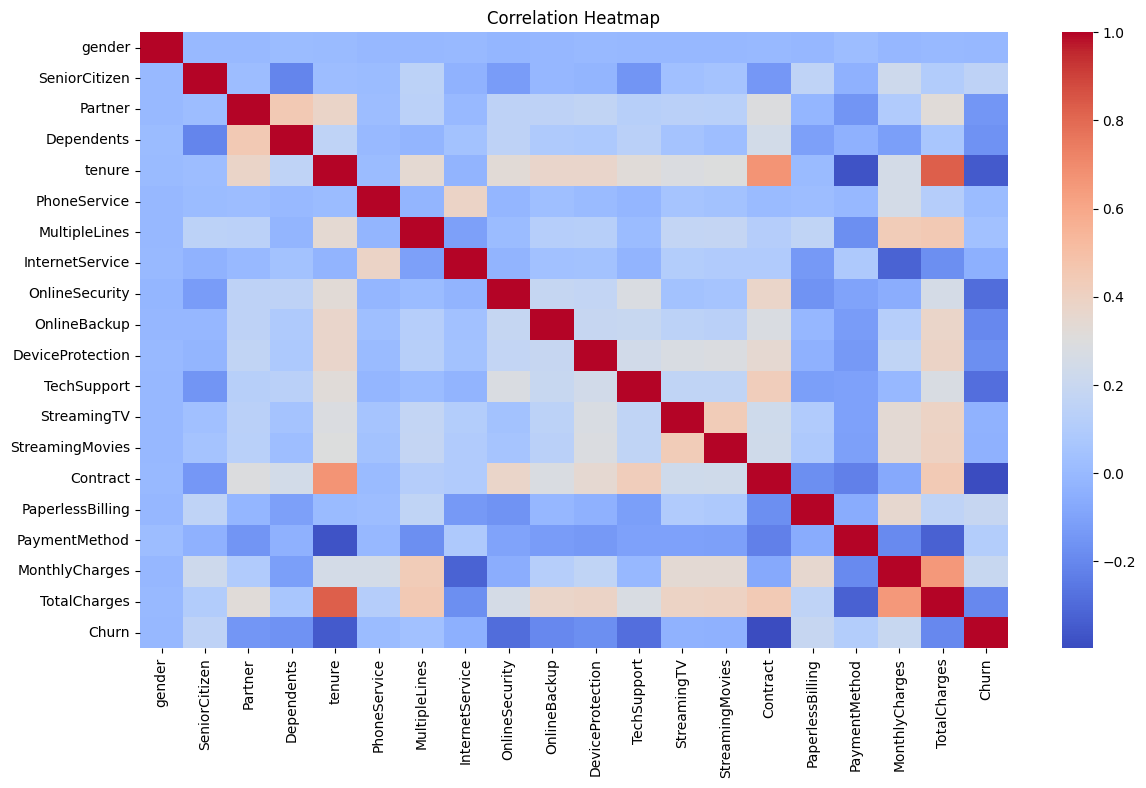

In [27]:
plt.figure(figsize=(14,8))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [28]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [29]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

In [30]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_prob = lr.predict_proba(X_test)[:,1]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [31]:
print("Accuracy:",
      accuracy_score(y_test, lr_pred))

print("Recall:",
      recall_score(y_test, lr_pred))

print("ROC AUC:",
      roc_auc_score(y_test, lr_prob))

print(classification_report(
    y_test,
    lr_pred
))

Accuracy: 0.7991483321504613
Recall: 0.553475935828877
ROC AUC: 0.8408587150275131
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [32]:
rf = RandomForestClassifier(

    n_estimators=200,

    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]

In [33]:
print("Accuracy:",
      accuracy_score(y_test, rf_pred))

print("Recall:",
      recall_score(y_test, rf_pred))

print("ROC AUC:",
      roc_auc_score(y_test, rf_prob))

Accuracy: 0.7892122072391767
Recall: 0.4893048128342246
ROC AUC: 0.825589656152316


In [ ]:
print(data)

     label                                            message  target  \
0      ham  Go until jurong point, crazy.. Available only ...       0   
1      ham                      Ok lar... Joking wif u oni...       0   
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...       1   
3      ham  U dun say so early hor... U c already then say...       0   
4      ham  Nah I don't think he goes to usf, he lives aro...       0   
...    ...                                                ...     ...   
5567  spam  This is the 2nd time we have tried 2 contact u...       1   
5568   ham              Will Ì_ b going to esplanade fr home?       0   
5569   ham  Pity, * was in mood for that. So...any other s...       0   
5570   ham  The guy did some bitching but I acted like i'd...       0   
5571   ham                         Rofl. Its true to its name       0   

                                          clean_message  
0     go jurong point crazy available bugis n great ...  
1      

In [34]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_prob = xgb.predict_proba(X_test)[:,1]

print("Accuracy:",
      accuracy_score(y_test,xgb_pred))

print("Recall:",
      recall_score(y_test,xgb_pred))

print("ROC AUC:",
      roc_auc_score(y_test,xgb_prob))

Accuracy: 0.7806955287437899
Recall: 0.516042780748663
ROC AUC: 0.8155971479500891


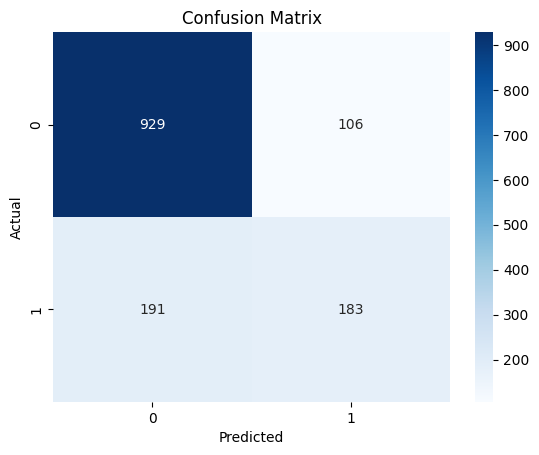

In [35]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

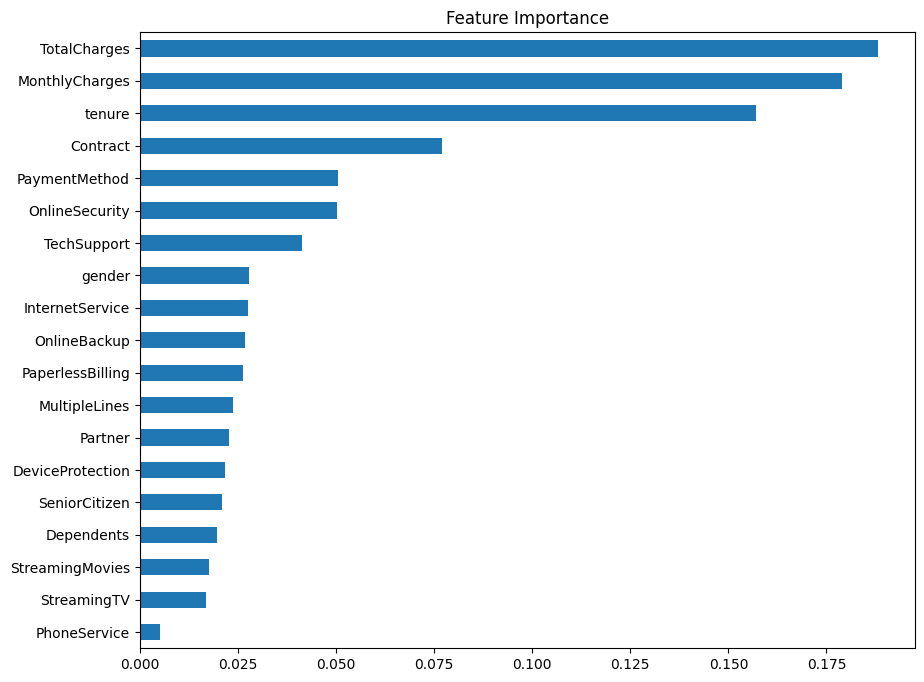

In [36]:
importance = pd.Series(

    rf.feature_importances_,

    index=X.columns

)

importance.sort_values().plot(

    kind="barh",

    figsize=(10,8)

)

plt.title("Feature Importance")

plt.show()

In [37]:
new_customer = X.iloc[[0]]

prediction = rf.predict(new_customer)

if prediction[0] == 1:
    print("Customer is likely to Churn")
else:
    print("Customer is likely to Stay")

Customer is likely to Stay


In [38]:
print("Customer Churn Prediction")

index = int(input("Enter Customer Index: "))

customer = X.iloc[[index]]

prediction = rf.predict(customer)

if prediction[0] == 1:
    print("Likely to Churn")
else:
    print("Not Likely to Churn")

Customer Churn Prediction
Enter Customer Index: 2
Likely to Churn
